In [2]:
import numpy as np
import pandas as pd
import pyopenms as ms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
from itertools import product
import string

# generate data table
Peptide sequences from library generation, generate [M+H]+ and [M+2H]2+

In [18]:
curated_library_unirep = np.load('data/curated_peptide_list.npy')

#Define modifications
linear = 'TAPAYDG'
lin_het_red = 'T[-18.01]APAYDG'
lin_het_ox = 'T[-20.02]APAYDG'
cyc = "TAP[-18.01]"
mods = [linear, lin_het_red, lin_het_ox, cyc]

# create pandas dataframe containing peptide seqs and their mass
df = pd.DataFrame(columns = ['linear', 'L(m+1)', 'L(m+2)', 'L(m+3)',
                             'lin+het+red', 'LHR(m+1)', 'LHR(m+2)','LHR(m+3)', 
                             'lin+het+ox', 'LHO(m+1)', 'LHO(m+2)','LHO(m+3)', 
                             'cyclic', 'C(m+1)', 'C(m+2)', 'C(m+3)'])

for j, pep in enumerate(curated_library_unirep):
    d = []
    for suffix in mods:
        seq_str = pep + suffix
        d.append(seq_str)
        seq = ms.AASequence.fromString(seq_str)
        for i in range(1,4):
            d.append(seq.getMonoWeight(ms.Residue.ResidueType.Full, int(i))/float(i))
    df.loc[j] = d

rows = list(string.ascii_uppercase[:8][::-1])
cols = list(range(1,13))
df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]

In [4]:
df.to_csv('data/peptide_mass_table.csv')
df.head()

,linear,L(m+1),L(m+2),L(m+3),lin+het+red,LHR(m+1),LHR(m+2),LHR(m+3),lin+het+ox,LHO(m+1),LHO(m+2),LHO(m+3),cyclic,C(m+1),C(m+2),C(m+3),well
0,DVQAFTAPAYDG,1254.563716,627.785496,418.859423,DVQAFT[-18.01]APAYDG,1236.553151,618.780214,412.855901,DVQAFT[-20.02]APAYDG,1234.543716,617.775496,412.186090,DVQAFTAP[-18.01],830.404299,415.705788,277.472951,A1
1,GYLKWTAPAYDG,1341.647385,671.327331,447.887313,GYLKWT[-18.01]APAYDG,1323.636820,662.322048,441.883791,GYLKWT[-20.02]APAYDG,1321.627385,661.317331,441.213979,GYLKWTAP[-18.01],917.487969,459.247623,306.500841,A2
2,GAEWRTAPAYDG,1293.585848,647.296562,431.866800,GAEWRT[-18.01]APAYDG,1275.575283,638.291280,425.863279,GAEWRT[-20.02]APAYDG,1273.565848,637.286562,425.193467,GAEWRTAP[-18.01],869.426431,435.216854,290.480328,A3
3,IDFVKTAPAYDG,1296.647051,648.827164,432.887201,IDFVKT[-18.01]APAYDG,1278.636486,639.821881,426.883680,IDFVKT[-20.02]APAYDG,1276.627051,638.817164,426.213868,IDFVKTAP[-18.01],872.487635,436.747456,291.500729,A4
4,WLYKDTAPAYDG,1399.652865,700.330071,467.222473,WLYKDT[-18.01]APAYDG,1381.642300,691.324788,461.218951,WLYKDT[-20.02]APAYDG,1379.632865,690.320071,460.549139,WLYKDTAP[-18.01],975.493449,488.250363,325.836001,A5


In [5]:
def extract_ioncount(exp, ions, rt_start, rt_end, MZ_tol=0.1):
    '''
    returns list of extracted ion counts of an mzML and
    intensity over time for a given spectrum 
    exp : [pyOpenMS experiment]
    ions: iterable of desired ion m/z values [float]
    rt_start: start acquisition retentiontime [seconds]
    rt_end: end acquisition retentiontime [seconds]
    MZ_tol: tolerance interval for m/z [float]
    '''
    N_scans = len(exp.getSpectra())
    ionCounts = np.zeros(len(ions))
    if PLOT==True:
        intensity = np.zeros((len(ions), N_scans))
    else: 
        intensity = None
        
    for j, ion in enumerate(ions):
        for i in range(N_scans):
            rt = exp.getSpectrum(i).getRT()
            if (rt>rt_start) and (rt<rt_end):
                mass, count = exp.getSpectrum(i).get_peaks()
                mask = (mass > (ion - MZ_tol)) & (mass < (ion + MZ_tol))
                ic = count[mask].sum()
                ionCounts[j] += ic
                
                if PLOT==True:
                    intensity[j,i] = ic
         
    return(list(ionCounts), intensity)

In [6]:
def make_heatmap(data, name, incubation_time, quantity='conversion'):
    rows = list(string.ascii_uppercase[:8][::-1])
    cols = list(range(1,13))
    quantity = 'conversion'

    data = np.array(result_df['conversion']).reshape((8,12))

    fig, ax = plt.subplots()
    im = ax.imshow(data, extent=[0, 12, 0, 8] )
    #ax.pcolormesh(data, edgecolors='k', linewidth=2)
    ax.grid(which = 'minor',color='w', linestyle='-', linewidth=2)
    plt.xticks(np.arange(len(cols))+0.5, labels=cols)
    ax.set_yticks(np.arange(len(rows))+0.5, labels=rows)
    plt.xlim(0,12)
    plt.title(name+' '+quantity+', '+incubation_time)

    #ax.grid(color='k', linestyle='-', linewidth=2)
    for j, i in product(np.arange(len(cols)),np.arange(len(rows))):
        l = ax.axvline(j, color='k', linewidth=2)
        l = ax.axhline(i, color='k', linewidth=2)

    cbar = ax.figure.colorbar(im, ax=ax, fraction=0.028, pad=0.04)
    cbar.ax.set_ylabel('% '+quantity, rotation=-90, va="bottom")

# Analyze PatG - 2 day reaction

In [7]:
PLOT=False
data_dir = 'data/PatG-2d/'
infiles = os.listdir(data_dir)
infiles = [data_dir+i for i in infiles if i.endswith('mzML') == True]

# define ions relevant for experiment type (which ions are relevant to observe)
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
cyclic_ions =  ['C(m+1)', 'C(m+2)', 'C(m+3)']
exp_ions = linear_ions + cyclic_ions

result_df = pd.DataFrame(columns=['peptide']+exp_ions)

# range of elution time that should be scanned
start = int(0.4*60)
end = 240

In [8]:
for infile in infiles:
    exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
    ions = df.loc[exp_num, exp_ions] # get the defined ions
    peptide = df.loc[exp_num, 'linear'] # get peptide sequence
    
    exp = ms.MSExperiment()
    ms.MzMLFile().load(infile, exp)
    
    ion_count, intensity = extract_ioncount(exp, ions, start, end)
    
    if PLOT==True:
        for i in range(len(ions)):
            col = ['r', 'b']
            if i <= 3: 
                plt.plot(intensity[i], color = col[0])
            else:
                plt.plot(intensity[i], color = col[1])
        plt.xlabel('Scans')
        plt.ylabel('Intensity')
        plt.title('PatG + '+peptide)
        red_patch = mpatches.Patch(color='red', label='linear peptide')
        blue_patch = mpatches.Patch(color='blue', label='cyclic peptide')
        plt.legend(loc='upper right', handles=[red_patch, blue_patch])
        plt.savefig('output_patg/'+str(exp_num)+'_PatG_'+peptide)
        plt.clf()
            
    result_df.loc[exp_num] = [peptide]+ion_count

# sum up ion counts of +1 to +3 charge states
result_df['L(tot)'] = result_df.loc[:,['L(m+1)', 'L(m+2)', 'L(m+3)']].sum(axis=1)
result_df['C(tot)'] = result_df.loc[:,['C(m+1)', 'C(m+2)', 'C(m+3)']].sum(axis=1)

# calculate conversion in % of cyclic to total product+starting material
result_df['conversion'] = result_df.loc[:,'C(tot)']/result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)*100

In [9]:
# sort again by index
result_df.sort_index(inplace=True)
# add names for wells to the data
rows = list(string.ascii_uppercase[:8][::-1])
cols = list(range(1,13))
result_df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]

# calculate total ion count of all linear and cyclic peptides
result_df['tot_ions'] = result_df.loc[:,['C(tot)', 'L(tot)']].sum(axis=1)
result_df.head()

,peptide,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,well,tot_ions
0,DVQAFTAPAYDG,7531986.0,19669095.0,59709.0,90420.0,70082.0,2867.0,27260790.0,163369.0,0.595712,A1,27424159.0
1,GYLKWTAPAYDG,1461095.0,24657462.0,447433.0,536007.0,547392.0,8481.0,26565990.0,1091880.0,3.947809,A2,27657870.0
2,GAEWRTAPAYDG,1017100.0,22716457.0,547222.0,62312.0,263037.0,2335.0,24280779.0,327684.0,1.331591,A3,24608463.0
3,IDFVKTAPAYDG,2002792.0,39992708.0,954651.0,133282.0,177017.0,3541.0,42950151.0,313840.0,0.725407,A4,43263991.0
4,WLYKDTAPAYDG,1185543.0,33413060.0,812739.0,600521.0,749243.0,8009.0,35411342.0,1357773.0,3.692700,A5,36769115.0


## False positive filtering
Crosscompare the total ion count with conversion values. Spectra were sorted by total ion count and all spectra were visually checked. 

**Observation**: Measurements with a total ion count < 1739627.0 seemed to be of poor quality and need to be repeated.

In [10]:
result_df.sort_values('tot_ions').head(14)

,peptide,L(m+1),L(m+2),L(m+3),C(m+1),C(m+2),C(m+3),L(tot),C(tot),conversion,well,tot_ions
78,YGENWTAPAYDG,170880.0,1279725.0,5910.0,116921.0,89592.0,78038.0,1456515.0,284551.0,16.343493,G7,1741066.0
94,ENFRDTAPAYDG,15955.0,1519895.0,76069.0,103871.0,68666.0,107418.0,1611919.0,279955.0,14.797761,H11,1891874.0
79,WEYGQTAPAYDG,427540.0,4466579.0,37548.0,146036.0,168712.0,14595.0,4931667.0,329343.0,6.260072,G8,5261010.0
92,FAKIYTAPAYDG,101262.0,5194129.0,181091.0,108883.0,91615.0,272819.0,5476482.0,473317.0,7.955176,H9,5949799.0
9,LDWEFTAPAYDG,878165.0,6895417.0,67010.0,68025.0,86731.0,7386.0,7840592.0,162142.0,2.026083,A10,8002734.0
46,FDWGATAPAYDG,1815371.0,8180204.0,53396.0,62671.0,76670.0,5547.0,10048971.0,144888.0,1.421326,D11,10193859.0
17,TYGFGTAPAYDG,2763860.0,6797974.0,17419.0,912670.0,194726.0,10590.0,9579253.0,1117986.0,10.451164,B6,10697239.0
13,YDAHATAPAYDG,208090.0,10134951.0,218158.0,183384.0,184467.0,2782.0,10561199.0,370633.0,3.390402,B2,10931832.0
31,DGYKNTAPAYDG,250686.0,10496785.0,142339.0,27528.0,35126.0,120726.0,10889810.0,183380.0,1.656072,C8,11073190.0
87,REYGNTAPAYDG,402565.0,11094157.0,351214.0,94459.0,133525.0,93868.0,11847936.0,321852.0,2.644680,H4,12169788.0


array([[<Axes: title={'center': 'conversion'}>,
        <Axes: title={'center': 'tot_ions'}>]], dtype=object)

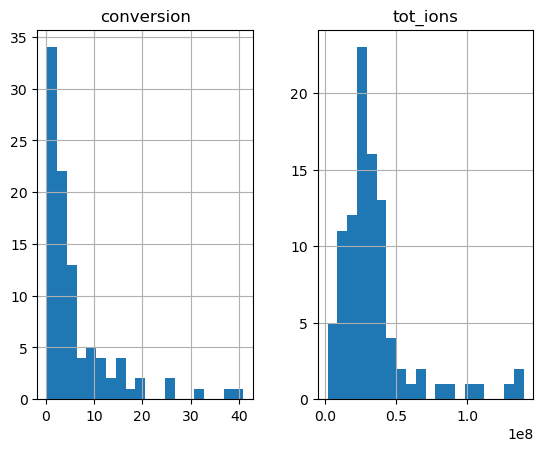

In [11]:
result_df.loc[:,['conversion', 'tot_ions']].hist(bins=20)

**Observation:** The top conversions stemmed from low ion count measurements. 

In [12]:
result_df.loc[:,['L(tot)','C(tot)','conversion','tot_ions']].describe()

,L(tot),C(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,3.132383e+07,2.959238e+06,6.389367,3.428307e+07
std,2.208124e+07,6.362670e+06,7.798381,2.601951e+07
min,1.456515e+06,6.325700e+04,0.353497,1.741066e+06
25%,1.834159e+07,3.199988e+05,1.619735,2.131992e+07
50%,2.750751e+07,7.843080e+05,3.352047,2.828116e+07
75%,3.583162e+07,1.874022e+06,8.046744,3.780930e+07
max,1.306356e+08,4.576898e+07,40.858831,1.395878e+08


__filter out samples with low ion count__

In [13]:
result_df['unfiltered_conversion'] = result_df['conversion']
result_df.loc[result_df['tot_ions'] < 1739627.0, 'conversion'] = 0
result_df.loc[:,['L(tot)','C(tot)','conversion','tot_ions']].describe()

,L(tot),C(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,3.132383e+07,2.959238e+06,6.389367,3.428307e+07
std,2.208124e+07,6.362670e+06,7.798381,2.601951e+07
min,1.456515e+06,6.325700e+04,0.353497,1.741066e+06
25%,1.834159e+07,3.199988e+05,1.619735,2.131992e+07
50%,2.750751e+07,7.843080e+05,3.352047,2.828116e+07
75%,3.583162e+07,1.874022e+06,8.046744,3.780930e+07
max,1.306356e+08,4.576898e+07,40.858831,1.395878e+08


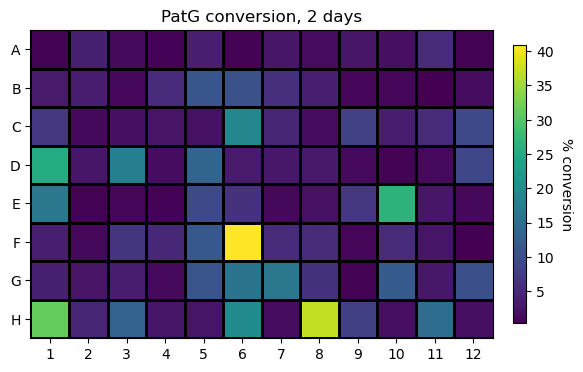

In [14]:
make_heatmap(result_df, 'PatG', '2 days','conversion')

## top 10 candidates for cyclization with PatG

In [15]:
result_df.to_csv('PatG-2d.csv')
result_df.sort_values('conversion', ascending=False).loc[:,['peptide','conversion']].head(10)

,peptide,conversion
65,ARYFQTAPAYDG,40.858831
91,WHRFTTAPAYDG,37.197500
84,IFRYETAPAYDG,31.298420
57,HRFLWTAPAYDG,26.472862
36,YRGAWTAPAYDG,25.252496
89,YLEKFTAPAYDG,19.838374
29,VENWYTAPAYDG,19.067205
38,QRWETTAPAYDG,17.799838
48,GRFYKTAPAYDG,16.475558
78,YGENWTAPAYDG,16.343493


# Analyze PatDfusion + ArtGox - 2 day reaction

In [21]:
PLOT=False
data_dir = 'data/PatDf-ArtG/'
infiles = os.listdir(data_dir)
infiles = [data_dir+i for i in infiles if i.endswith('mzML') == True]

# define ions relevant for experiment type (which ions are relevant to observe)
linear_ions = ['L(m+1)', 'L(m+2)', 'L(m+3)']
lhr = ['LHR(m+1)', 'LHR(m+2)','LHR(m+3)']
lho = ['LHO(m+1)', 'LHO(m+2)','LHO(m+3)' ]

#combined list with expected ions
exp_ions = linear_ions + lhr + lho

result_df = pd.DataFrame(columns=['peptide']+exp_ions)

# range of elution time that should be scanned
start = 0.4*60
end = 240

In [22]:
for infile in infiles:
    exp_num = int(infile.split('2d-')[1].split('_')[0]) - 1 # -1 because files are 1 indexed
    ions = df.loc[exp_num, exp_ions] # get the defined ions
    peptide = df.loc[exp_num, 'linear'] # get peptide sequence
    
    exp = ms.MSExperiment()
    ms.MzMLFile().load(infile, exp)
    
    ion_count, intensity = extract_ioncount(exp, ions, start, end)
    
    if PLOT==True:
        for i in range(len(ions)):
            col = ['r', 'b', 'k']
            if i <= 3: 
                plt.plot(intensity[i], color = col[0])
            elif i >= 6:
                plt.plot(intensity[i], color = col[2])
            else:
                plt.plot(intensity[i], color = col[1])
        plt.xlabel('Scans')
        plt.ylabel('Intensity')
        plt.title('PatDf+ArtGox + '+peptide)
        red_patch = mpatches.Patch(color='red', label='linear peptide')
        blue_patch = mpatches.Patch(color='blue', label='heterocyclic reduced')
        black_patch = mpatches.Patch(color='k', label='heterocyclic oxidized')
        plt.legend(loc='upper right', handles=[red_patch, blue_patch, black_patch])
        plt.savefig('output_patdf_artgox/'+str(exp_num)+'_PatDf_ArtGox_'+peptide)
        plt.clf()
            
    result_df.loc[exp_num] = [peptide]+ion_count

# sum up ion counts of +1 to +3 charge states
result_df['L(tot)'] = result_df.loc[:,['L(m+1)', 'L(m+2)', 'L(m+3)']].sum(axis=1)
result_df['LHR(tot)'] = result_df.loc[:,lhr].sum(axis=1)
result_df['LHO(tot)'] = result_df.loc[:,lho].sum(axis=1)


In [23]:
# calculate conversion in % of cyclic to total product+starting material
result_df['conversion'] = result_df.loc[:,['LHO(tot)','LHR(tot)']].sum(axis=1)/result_df.loc[:,['LHO(tot)', 'LHR(tot)', 'L(tot)']].sum(axis=1)*100
result_df['tot_ions'] = result_df.loc[:, exp_ions].sum(axis=1)

In [24]:
result_df.sort_values('tot_ions').head(10)


,peptide,L(m+1),L(m+2),L(m+3),LHR(m+1),LHR(m+2),LHR(m+3),LHO(m+1),LHO(m+2),LHO(m+3),L(tot),LHR(tot),LHO(tot),conversion,tot_ions
64,AFWKVTAPAYDG,207.0,5943.0,994.0,962.0,2062.0,663.0,692.0,2313.0,4129.0,7144.0,3687.0,7134.0,60.233788,17965.0
78,YGENWTAPAYDG,216.0,1656.0,1438.0,888.0,2148.0,784.0,533.0,2742.0,8143.0,3310.0,3820.0,11418.0,82.154410,18548.0
54,KEYGNTAPAYDG,911.0,2759.0,5211.0,698.0,2830.0,5253.0,929.0,2437.0,1122.0,8881.0,8781.0,4488.0,59.905192,22150.0
66,WIETATAPAYDG,367.0,4524.0,4446.0,671.0,4744.0,2706.0,896.0,2753.0,1455.0,9337.0,8121.0,5104.0,58.616257,22562.0
53,YLHRITAPAYDG,537.0,5262.0,1145.0,347.0,4089.0,907.0,230.0,4393.0,5794.0,6944.0,5343.0,10417.0,69.415081,22704.0
88,YEIAYTAPAYDG,680.0,4918.0,4772.0,552.0,2833.0,4917.0,1027.0,4067.0,1940.0,10370.0,8302.0,7034.0,59.659224,25706.0
42,FQYTRTAPAYDG,259.0,2432.0,4848.0,101.0,2079.0,9448.0,110.0,2608.0,3980.0,7539.0,11628.0,6698.0,70.852503,25865.0
51,WDLKYTAPAYDG,525.0,3920.0,6262.0,234.0,4061.0,5260.0,573.0,3661.0,1726.0,10707.0,9555.0,5960.0,59.167874,26222.0
77,GFDKWTAPAYDG,249.0,3492.0,5865.0,162.0,3779.0,8438.0,694.0,3106.0,1178.0,9606.0,12379.0,4978.0,64.373401,26963.0
27,QKLEYTAPAYDG,571.0,2919.0,2447.0,675.0,6184.0,2120.0,713.0,3263.0,8246.0,5937.0,8979.0,12222.0,78.122927,27138.0


In [25]:
result_df.sort_index(inplace=True)
result_df['well'] = [''.join([i,str(j)]) for i, j in list(product(rows, cols[::-1]))[::-1]]
result_df.head()

,peptide,L(m+1),L(m+2),L(m+3),LHR(m+1),LHR(m+2),LHR(m+3),LHO(m+1),LHO(m+2),LHO(m+3),L(tot),LHR(tot),LHO(tot),conversion,tot_ions,well
0,DVQAFTAPAYDG,1686.0,56219.0,84035.0,2983.0,56674.0,34269.0,3036.0,81541.0,107471.0,141940.0,93926.0,192048.0,66.829784,427914.0,A1
1,GYLKWTAPAYDG,879373.0,15115508.0,390668.0,6753.0,567718.0,112996.0,3869.0,52673.0,672522.0,16385549.0,687467.0,729064.0,7.957110,17802080.0,A2
2,GAEWRTAPAYDG,798900.0,15902295.0,432782.0,9275.0,621141.0,64547.0,2115.0,45513.0,82618.0,17133977.0,694963.0,130246.0,4.594913,17959186.0,A3
3,IDFVKTAPAYDG,22250.0,4036352.0,117182.0,1473.0,170141.0,132628.0,1109.0,27425.0,66958.0,4175784.0,304242.0,95492.0,8.736366,4575518.0,A4
4,WLYKDTAPAYDG,765482.0,20651493.0,589353.0,6214.0,1259994.0,92593.0,2695.0,59797.0,37920.0,22006328.0,1358801.0,100412.0,6.218536,23465541.0,A5


In [26]:
result_df.loc[:,['L(tot)','LHR(tot)','LHO(tot)','conversion','tot_ions']].describe()

,L(tot),LHR(tot),LHO(tot),conversion,tot_ions
count,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,1.225722e+07,7.687902e+05,1.281560e+05,26.653953,1.315417e+07
std,1.101387e+07,9.690701e+05,2.422438e+05,30.142259,1.183902e+07
min,3.310000e+03,3.455000e+03,4.488000e+03,3.089489,1.796500e+04
25%,1.388850e+04,1.350550e+04,2.005250e+04,5.162246,5.152725e+04
50%,1.116235e+07,5.808740e+05,8.620100e+04,7.625186,1.167549e+07
75%,2.118437e+07,1.134572e+06,1.436432e+05,59.987341,2.353111e+07
max,3.653683e+07,5.365863e+06,2.154369e+06,88.594779,3.897426e+07


In [30]:
cutoff = 4826505.0
quantity = 'conversion'
result_df['unfiltered_conversion'] = result_df['conversion']
result_df.loc[result_df['tot_ions'] < cutoff, quantity] = 0
result_df.loc[:,['L(tot)','LHR(tot)','LHO(tot)', 'unfiltered_conversion', 'conversion','tot_ions']].describe()

,L(tot),LHR(tot),LHO(tot),unfiltered_conversion,conversion,tot_ions
count,9.600000e+01,9.600000e+01,9.600000e+01,9.600000e+01,96.000000,9.600000e+01
mean,1.225722e+07,7.687902e+05,1.281560e+05,3.854167e+08,3.947507,1.315417e+07
std,1.101387e+07,9.690701e+05,2.422438e+05,4.892484e+08,4.145982,1.183902e+07
min,3.310000e+03,3.455000e+03,4.488000e+03,3.089489e+00,0.000000,1.796500e+04
25%,1.388850e+04,1.350550e+04,2.005250e+04,5.240533e+00,0.000000,5.152725e+04
50%,1.116235e+07,5.808740e+05,8.620100e+04,7.953096e+00,4.359186,1.167549e+07
75%,2.118437e+07,1.134572e+06,1.436432e+05,1.000000e+09,5.758516,2.353111e+07
max,3.653683e+07,5.365863e+06,2.154369e+06,1.000000e+09,24.230999,3.897426e+07


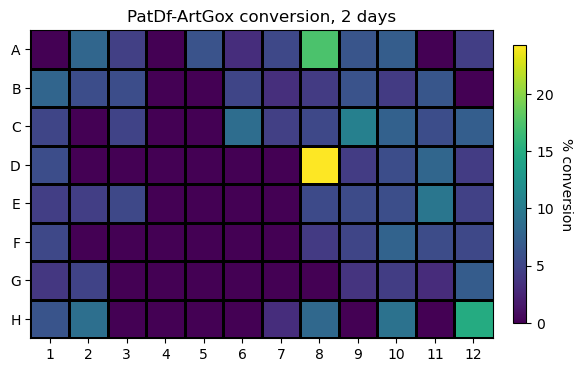

In [31]:
make_heatmap(result_df, 'PatDf-ArtGox', '2 days', 'conversion')

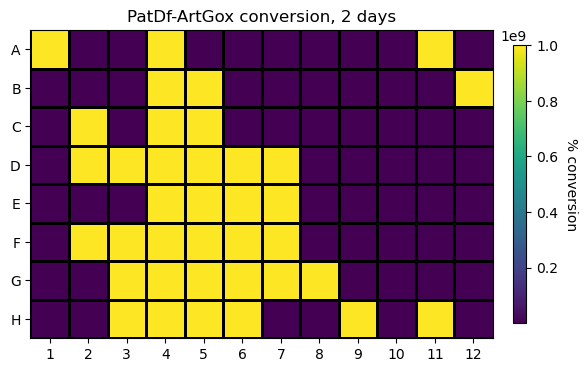

In [29]:
make_heatmap(result_df, 'PatDf-ArtGox', '2 days', 'conversion')

In [32]:
result_df.to_csv('PatDf-ArtGox-2d.csv')
result_df.sort_values('conversion', ascending=False).loc[:,['conversion','peptide','well']].head(10)

,conversion,peptide,well
43,24.230999,KWENFTAPAYDG,D8
7,17.324383,YVLRYTAPAYDG,A8
95,14.899716,FIRYQTAPAYDG,H12
32,10.575966,VKFWHTAPAYDG,C9
58,9.502828,KHFAATAPAYDG,E11
93,9.143483,ERIWQTAPAYDG,H10
85,8.841998,HFEAYTAPAYDG,H2
29,8.622504,VENWYTAPAYDG,C6
91,8.153581,WHRFTTAPAYDG,H8
46,7.985647,FDWGATAPAYDG,D11


In [33]:
result_df.sort_values('conversion', ascending=False).loc[:,['peptide','conversion']].to_csv('PatDf-ArtGox-ranking.csv')